# 04 - Evaluation: Urban -> Rural (Distribution Shift)

Applies the Logistic Regression model trained on urban data to rural accident data.
This is the core distribution shift experiment -- the model has never seen rural road contexts.

| Dataset | Rows | Fatal | Fatality rate |
|---|---|---|---|
| Urban (train, full) | 3,544 | 64 | 1.81% |
| Rural (test) | 1,421 | 70 | 4.93% |

**Steps**
1. Retrain LR on full urban set
2. Feature engineering helper (mirrors notebook 02)
3. Load & engineer rural data
4. Align columns to urban feature space
5. Evaluate on rural set
6. Threshold calibration
7. Summary comparison

**Key finding:** urban -> rural ROC-AUC drop quantifies the cost of distribution shift.
The calibrated threshold from urban val does not transfer well to rural -- see Section 6.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42

## 1. Retrain LR on Full Urban Set

In notebook 03 we held out 20% for validation.
Here we train on the full urban set so the model has seen as many fatal cases as possible
before evaluating on rural.

In [4]:
# -- Data paths -- update to your local environment
DATA_DIR = '../data/'
urban = pd.read_csv(DATA_DIR + 'urban_features.csv')

X_urban = urban.drop(columns=['is_fatal'])
y_urban = urban['is_fatal']
train_cols = X_urban.columns.tolist()

scaler = StandardScaler()
X_urban_sc = scaler.fit_transform(X_urban)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_urban_sc, y_urban)

print(f'Model trained on {len(urban):,} urban accidents ({y_urban.sum()} fatal).')
print(f'Training features: {len(train_cols)}')

Model trained on 3,544 urban accidents (64 fatal).
Training features: 83


## 2. Feature Engineering Helper

Identical transformations to notebook 02, applied to rural raw data.

Key differences from urban:
- `settlement` excluded from OHE (549 unique rural values vs 22 urban -- all map to zero after alignment)
- Speed filter already applied in SQL -- no speed filtering here

In [5]:
def engineer_features(df_raw):
    df = df_raw.copy()

    # Target
    df['is_fatal'] = (df['deaths'].fillna(0) > 0).astype(int)

    # Speed limit remap -- same mapping as notebook 02
    df['speed_limit'] = df['speed_limit'].replace(
        {5: 20, 10: 20, 15: 20, 25: 30, 45: 40, 60: 70, 80: 70}
    )

    # Road width bin -- same bins as notebook 02
    df['road_width_bin'] = pd.cut(
        df['road_width'],
        bins=[0, 5, 9, 14, np.inf],
        labels=['narrow', 'standard', 'wide', 'arterial'],
        right=True
    )

    # Temporal features
    df['accident_time'] = pd.to_datetime(df['accident_time'])
    hour = df['accident_time'].dt.hour
    dow  = df['accident_time'].dt.dayofweek

    def assign_hour_bin(h):
        if h in range(22, 24) or h in range(0, 6):           return 'night'
        elif h in list(range(7, 10)) + list(range(15, 19)):  return 'rush'
        elif h in range(19, 22):                              return 'evening'
        else:                                                 return 'day'

    df['hour_bin']   = hour.map(assign_hour_bin)
    df['is_weekend'] = (dow >= 5).astype(int)

    # OHE -- settlement excluded (see notebook header)
    OHE_COLS = [
        'accident_type', 'accident_type_detailed',
        'road_condition', 'weather', 'lighting',
        'road_width_bin', 'hour_bin',
    ]
    df = pd.get_dummies(df, columns=[c for c in OHE_COLS if c in df.columns],
                        drop_first=False, dtype=int)

    # Drop same columns as notebook 02
    DROP_COLS = [
        'deaths', 'injured',
        'road_type_detailed', 'road_surface_condition',
        'accident_scenario', 'join_distance',
        'road_type', 'road_width',
        'x_coord', 'y_coord',
        'accident_id', 'accident_time',
        'county', 'municipality', 'settlement',
        'involving_motorvehicle_driver',
    ]
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    return df


def align_columns(df, train_cols):
    """
    Align test set columns to training feature space.
    - Columns in train but missing from test: add as zeros (unseen urban categories)
    - Columns in test but not in train: drop (rural-only categories)
    """
    missing = set(train_cols) - set(df.columns)
    extra   = set(df.columns) - set(train_cols) - {'is_fatal'}

    for col in missing:
        df[col] = 0
    df = df.drop(columns=list(extra), errors='ignore')
    df = df[train_cols + ['is_fatal']]

    if missing: print(f'  Added {len(missing)} missing columns as zeros')
    if extra:   print(f'  Dropped {len(extra)} rural-only columns')
    return df


print('Helper functions defined.')

Helper functions defined.


## 3. Load & Engineer Rural Data

In [6]:
# Google Colab -- remove before committing
from google.colab import drive
drive.mount('/content/drive')
rural_raw = pd.read_csv('/content/drive/MyDrive/Analytics course/rural_set.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# -- Data paths -- update to your local environment
# rural_raw = pd.read_csv(DATA_DIR + 'rural_filter.csv')

print(f'Rural raw: {rural_raw.shape[0]:,} rows x {rural_raw.shape[1]} columns')

rural = engineer_features(rural_raw)
print(f'After engineering: {rural.shape}')
print(f'Fatal: {rural["is_fatal"].sum()} ({rural["is_fatal"].mean()*100:.2f}%)')

Rural raw: 1,421 rows x 27 columns
After engineering: (1421, 51)
Fatal: 70 (4.93%)


## 4. Align Columns to Urban Feature Space

In [8]:
rural = align_columns(rural, train_cols)
print(f'Rural aligned: {rural.shape}')
assert rural.shape[1] == len(train_cols) + 1, 'Column count mismatch after alignment'

  Added 35 missing columns as zeros
  Dropped 2 rural-only columns
Rural aligned: (1421, 84)


## 5. Evaluate on Rural Set

In [9]:
def evaluate(name, df, model, scaler, train_cols):
    X = df[train_cols]
    y = df['is_fatal']
    X_sc  = scaler.transform(X)
    preds = model.predict(X_sc)
    proba = model.predict_proba(X_sc)[:, 1]
    roc   = roc_auc_score(y, proba)
    pr    = average_precision_score(y, proba)

    print(f'\n{"="*52}')
    print(f'  {name}')
    print(f'  n={len(y):,}  |  fatal={y.sum()}  |  fatality rate={y.mean()*100:.2f}%')
    print(f'  ROC-AUC: {roc:.4f}   PR-AUC: {pr:.4f}')
    print(f'{"="*52}')
    print(classification_report(y, preds, target_names=['non-fatal', 'fatal'], digits=3))
    cm = confusion_matrix(y, preds)
    print('Confusion matrix:')
    print(cm)
    print('  [TN  FP]')
    print('  [FN  TP]')

    return {'name': name, 'y': y, 'proba': proba, 'preds': preds, 'roc': roc, 'pr': pr}


rural_res = evaluate('Rural', rural, lr, scaler, train_cols)


  Rural
  n=1,421  |  fatal=70  |  fatality rate=4.93%
  ROC-AUC: 0.6350   PR-AUC: 0.1007
              precision    recall  f1-score   support

   non-fatal      0.965     0.715     0.821      1351
       fatal      0.083     0.500     0.143        70

    accuracy                          0.704      1421
   macro avg      0.524     0.608     0.482      1421
weighted avg      0.922     0.704     0.788      1421

Confusion matrix:
[[966 385]
 [ 35  35]]
  [TN  FP]
  [FN  TP]


## 6. Threshold Calibration

Threshold is calibrated on a reconstructed urban val split (same `random_state=42` as notebook 03).
Then applied to rural to show whether the optimal urban threshold transfers.

**Expected finding:** the urban-calibrated threshold is too conservative for rural --
rural fatal cases receive lower predicted probabilities due to distribution shift,
so recall drops when the urban threshold is applied.

In [10]:
def best_threshold(y_true, proba):
    prec, rec, thresholds = precision_recall_curve(y_true, proba)
    f1 = np.where((prec + rec) == 0, 0, 2 * prec * rec / (prec + rec))
    idx = np.argmax(f1[:-1])
    return thresholds[idx], prec[idx], rec[idx], f1[idx]

# Reconstruct urban val split
_, X_val_sc, _, y_val = train_test_split(
    X_urban_sc, y_urban, test_size=0.2, random_state=RANDOM_STATE, stratify=y_urban
)
lr_val_proba = lr.predict_proba(X_val_sc)[:, 1]
best_t, best_p, best_r, best_f = best_threshold(y_val, lr_val_proba)

print(f'Best threshold (urban val): {best_t:.4f}')
print(f'  Precision: {best_p:.4f}  |  Recall: {best_r:.4f}  |  F1: {best_f:.4f}')

print('\n--- Rural -- default threshold ---')
print(classification_report(rural_res['y'], rural_res['preds'],
                             target_names=['non-fatal', 'fatal'], digits=3))

rural_preds_recal = (rural_res['proba'] >= best_t).astype(int)
print(f'--- Rural -- recalibrated threshold ({best_t:.4f}) ---')
print(classification_report(rural_res['y'], rural_preds_recal,
                             target_names=['non-fatal', 'fatal'], digits=3))
print(confusion_matrix(rural_res['y'], rural_preds_recal))
print('  [TN  FP]')
print('  [FN  TP]')

Best threshold (urban val): 0.7965
  Precision: 0.1045  |  Recall: 0.5385  |  F1: 0.1750

--- Rural -- default threshold ---
              precision    recall  f1-score   support

   non-fatal      0.965     0.715     0.821      1351
       fatal      0.083     0.500     0.143        70

    accuracy                          0.704      1421
   macro avg      0.524     0.608     0.482      1421
weighted avg      0.922     0.704     0.788      1421

--- Rural -- recalibrated threshold (0.7965) ---
              precision    recall  f1-score   support

   non-fatal      0.956     0.893     0.924      1351
       fatal      0.094     0.214     0.131        70

    accuracy                          0.860      1421
   macro avg      0.525     0.554     0.527      1421
weighted avg      0.914     0.860     0.885      1421

[[1207  144]
 [  55   15]]
  [TN  FP]
  [FN  TP]


/tmp/ipykernel_2742/1998574890.py:3: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((prec + rec) == 0, 0, 2 * prec * rec / (prec + rec))


## 7. Summary Comparison

Urban validation results carried over from notebook 03.

In [11]:
# Urban val reference numbers -- update after running notebook 03
URBAN_VAL = {
    'roc':       0.6680,
    'pr':        0.0336,
    'recall':    0.615,
    'tp':        8,
    'fn':        5,
    'fatal_n':   13,
}

rural_cm = confusion_matrix(rural_res['y'], rural_res['preds'])
tn, fp, fn, tp = rural_cm.ravel()
rural_recall = tp / (tp + fn)

print(f'{"Context":<25} {"ROC-AUC":>8} {"PR-AUC":>8} {"Recall":>8} {"TP":>6} {"FN":>6}')
print('-' * 65)
print(f'{"Urban (val)":<25} {URBAN_VAL["roc"]:>8.4f} {URBAN_VAL["pr"]:>8.4f} {URBAN_VAL["recall"]:>8.3f} {URBAN_VAL["tp"]:>6} {URBAN_VAL["fn"]:>6}')
print(f'{"Rural (test)":<25} {rural_res["roc"]:>8.4f} {rural_res["pr"]:>8.4f} {rural_recall:>8.3f} {tp:>6} {fn:>6}')
print()
print(f'ROC-AUC drop (distribution shift): {URBAN_VAL["roc"] - rural_res["roc"]:.4f}')

Context                    ROC-AUC   PR-AUC   Recall     TP     FN
-----------------------------------------------------------------
Urban (val)                 0.6680   0.0336    0.615      8      5
Rural (test)                0.6350   0.1007    0.500     35     35

ROC-AUC drop (distribution shift): 0.0330


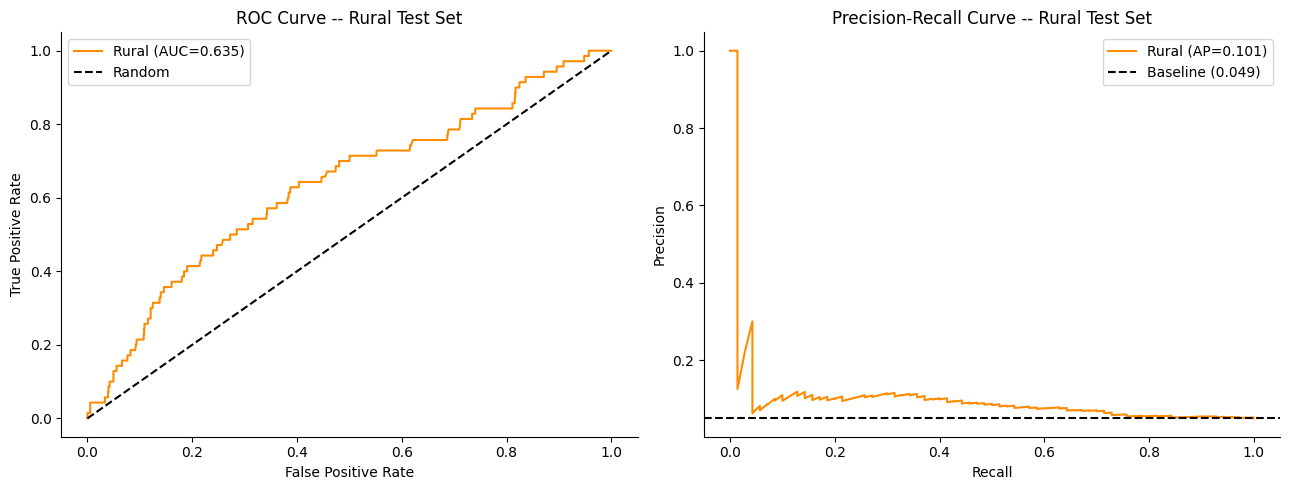

In [12]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(rural_res['y'], rural_res['proba'])
axes[0].plot(fpr, tpr, color='darkorange', label=f'Rural (AUC={rural_res["roc"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve -- Rural Test Set')
axes[0].legend()
sns.despine(ax=axes[0])

prec, rec, _ = precision_recall_curve(rural_res['y'], rural_res['proba'])
axes[1].plot(rec, prec, color='darkorange', label=f'Rural (AP={rural_res["pr"]:.3f})')
axes[1].axhline(rural_res['y'].mean(), color='k', linestyle='--',
                label=f'Baseline ({rural_res["y"].mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve -- Rural Test Set')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('roc_pr_rural.png', dpi=150)
plt.show()

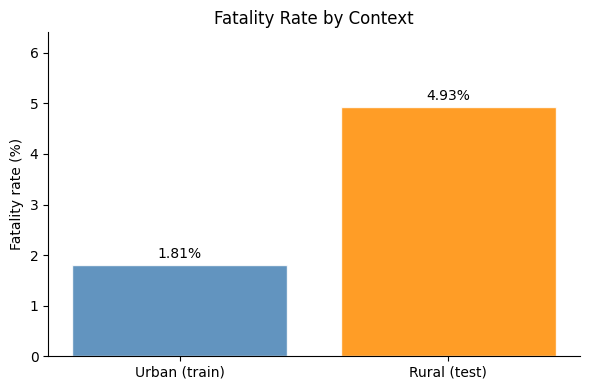

In [13]:
# Fatality rate by context
contexts = {
    'Urban (train)': y_urban.mean() * 100,
    'Rural (test)':  rural['is_fatal'].mean() * 100,
}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(contexts.keys(), contexts.values(),
              color=['steelblue', 'darkorange'], alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='{:.2f}%', padding=3)
ax.set_ylabel('Fatality rate (%)')
ax.set_title('Fatality Rate by Context')
ax.set_ylim(0, max(contexts.values()) * 1.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('fatality_rate_by_context.png', dpi=150)
plt.show()

---

## Summary

| Context | n | Fatal | Fatality rate | ROC-AUC | PR-AUC | Recall |
|---|---|---|---|---|---|---|
| Urban (val) | 709 | 13 | 1.84% | 0.6680 | 0.0336 | 0.615 |
| Rural (test) | 1,421 | 70 | 4.93% | 0.6350 | 0.1007 | 0.500 |


**Key finding:** ROC-AUC drops from urban val to rural test, quantifying the distribution shift cost.
The urban-calibrated threshold does not transfer -- rural fatal cases receive lower predicted probabilities,
so recall falls when the urban threshold is applied.

**Next -> `05_flipped_experiment.ipynb`:** reverse the experiment -- train on rural, test on urban.